⏳ Loading target dataset: 'churn-bigml-20.csv'...
⚙️ Engineering feature scales and training Logistic Regression model...

📊 Extracting and decoding model weights into business odds ratios...

             LOGISTIC REGRESSION COEFFICIENT INTERPRETATION
               Feature Log-Odds Coefficient Odds Ratio (e^coef)
              State_SD               1.2065              3.3418
International plan_Yes               1.1572              3.1809
              State_CA               1.1284              3.0906
              State_MT               1.0555              2.8733
Customer service calls               0.9933              2.7003
              State_RI               0.9469              2.5778
              State_CO               0.7341              2.0837
              State_NJ               0.6830              1.9799
              State_ID               0.6665              1.9473
              State_MD               0.6231              1.8647
              State_NV               0.5479

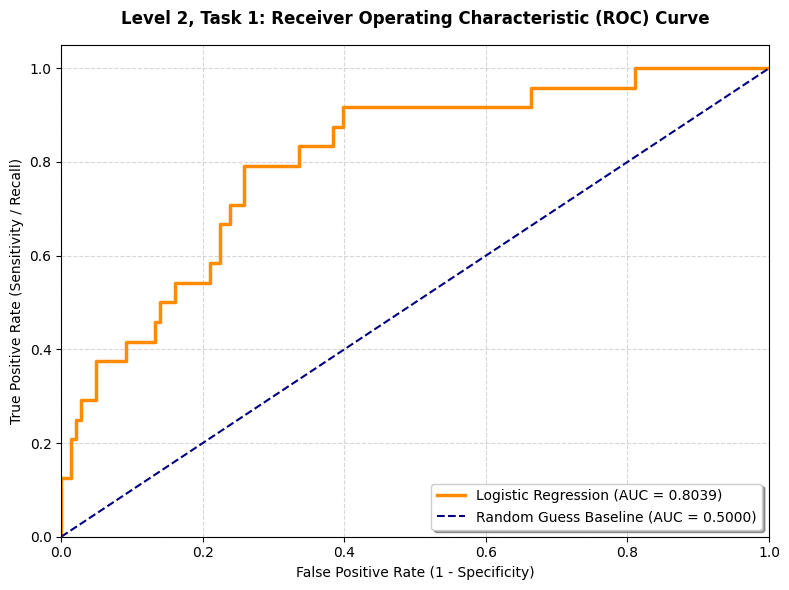


✔️ Process complete! Review your terminal table and active graphics display.


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# =====================================================================
# 1. DATA INGESTION & STRUCTURAL SETUP
# =====================================================================
filename = 'churn-bigml-20.csv'

if not os.path.exists(filename):
    raise FileNotFoundError(
        f"Missing dataset file '{filename}' in directory '{os.getcwd()}'. "
        f"Please verify it is uploaded to your environment before running."
    )

print(f"⏳ Loading target dataset: '{filename}'...")
df = pd.read_csv(filename)

# Isolate features (X) and target class labels (y)
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)

# Stratify the train/test split to handle imbalanced customer retention weights safely
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# =====================================================================
# 2. FEATURE ENGINEERING & EXTRACTION PIPELINE
# =====================================================================
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define structural pipelines to transform numeric and category metrics smoothly
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Build a unified pipeline integrating preprocessing and weighted Logistic Regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# =====================================================================
# 3. TRAINING THE REGRESSION BASELINE
# =====================================================================
print("⚙️ Engineering feature scales and training Logistic Regression model...")
model_pipeline.fit(X_train, y_train)

# =====================================================================
# 4. MATH INTERPRETATION: COEFFICIENTS & ODDS RATIOS
# =====================================================================
print("\n📊 Extracting and decoding model weights into business odds ratios...")

# Safely extract feature names newly minted from the preprocessing phase
encoded_cat_names = model_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(encoded_cat_names)

# Pull the raw directional coefficients from the trained regression model
raw_coefficients = model_pipeline.named_steps['classifier'].coef_[0]

# Calculate the Odds Ratios using exponential scaling: Odds = exp(Coef)
odds_ratios = np.exp(raw_coefficients)

# Construct a clean summary table for interpretation
coef_summary_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Log-Odds Coefficient': raw_coefficients,
    'Odds Ratio (e^coef)': odds_ratios
}).sort_values(by='Odds Ratio (e^coef)', ascending=False)

print("\n" + "="*70)
print("             LOGISTIC REGRESSION COEFFICIENT INTERPRETATION")
print("="*70)
print(coef_summary_df.to_string(index=False, formatters={
    'Log-Odds Coefficient': '{:,.4f}'.format,
    'Odds Ratio (e^coef)': '{:,.4f}'.format
}))
print("="*70)

# =====================================================================
# 5. DIAGNOSTIC EVALUATION MATRIX SCORECARD
# =====================================================================
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

print("\n" + "="*55)
print("           LOGISTIC REGRESSION PERFORMANCE SCORECARD")
print("="*55)
print(f"Overall Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("-"*55)
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))
print("-"*55)
print("Confusion Matrix Matrix Blueprint:")
print(confusion_matrix(y_test, y_pred))
print("="*55)

# =====================================================================
# 6. SYLLABUS REQUIREMENT: PLOTTING THE ROC CURVE
# =====================================================================
print("\n📈 Generating Receiver Operating Characteristic (ROC) curve plot...")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess Baseline (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=10)
plt.title('Level 2, Task 1: Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold', pad=15)
plt.legend(loc="lower right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n✔️ Process complete! Review your terminal table and active graphics display.")